# Case Capim - Analista de Crédito e ML

### imports iniciais e leitura dos dados

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_contratos = pd.read_excel('Base de Contratos.xlsx')
df_parcelas = pd.read_excel('Base de Parcelas.xlsx')

df_contratos.head()

,ID_CONTRATO,VALOR_EMPRESTADO,PRAZO_MESES,SCORE_CREDITO,IDADE,ESTADO,PROFISSAO,RENDA_ESTIMADA,DATA_CONTRATACAO
0,202691,2400.0,20,850.0,45,SP,autonomous,9500.0,2025-11-14
1,144498,3900.0,24,874.0,38,PR,public_agent,3050.0,2025-01-10
2,183536,3700.0,12,672.0,55,PR,autonomous,1600.0,2025-07-29
3,194201,1200.0,10,788.0,68,BA,retired,6050.0,2025-09-27
4,190540,8800.0,24,779.0,54,SP,wage_worker,1800.0,2025-09-06


In [11]:
df_parcelas.head()

,ID_CONTRATO,NUMERO_PARCELA,VALOR_PARCELA,DATA_VENCIMENTO,DATA_PAGAMENTO
0,174323,2,184.29,2025-08-15,2025-08-16
1,174323,1,184.29,2025-07-15,2025-07-16
2,174323,8,184.29,2026-02-15,NaT
3,174323,9,184.29,2026-03-15,NaT
4,174323,10,184.29,2026-04-15,NaT


## Análise exploratória inicial

In [12]:
n_contratos = df_contratos['ID_CONTRATO'].nunique()
n_parcelas = len(df_parcelas)
n_linhas_contratos = len(df_contratos)

print(f"Total de linhas na base de contratos (df_contratos): {n_linhas_contratos}")
print(f"Contratos únicos (df_contratos): {n_contratos}")
print(f"Linhas na base de parcelas (df_parcelas): {n_parcelas}")

Total de linhas na base de contratos (df_contratos): 300
Contratos únicos (df_contratos): 300
Linhas na base de parcelas (df_parcelas): 5659


In [13]:
print("=== Nulos em df_contratos ===")
nulos_contratos = df_contratos.isnull().sum()
pct_contratos = (nulos_contratos / len(df_contratos) * 100).round(2)
resumo_contratos = pd.DataFrame({'nulos': nulos_contratos, '%': pct_contratos})
print(resumo_contratos[resumo_contratos['nulos'] > 0].to_string() or "Sem valores nulos")

print("\n=== Nulos em df_parcelas ===")
nulos_parcelas = df_parcelas.isnull().sum()
pct_parcelas = (nulos_parcelas / len(df_parcelas) * 100).round(2)
resumo_parcelas = pd.DataFrame({'nulos': nulos_parcelas, '%': pct_parcelas})
print(resumo_parcelas[resumo_parcelas['nulos'] > 0].to_string() or "Sem valores nulos")

=== Nulos em df_contratos ===
                nulos      %
SCORE_CREDITO      24   8.00
PROFISSAO          13   4.33
RENDA_ESTIMADA    108  36.00

=== Nulos em df_parcelas ===
                nulos      %
DATA_PAGAMENTO   3315  58.58


In [14]:
print(f"ESTADO — {df_contratos['ESTADO'].nunique()} valores únicos:")
print(sorted(df_contratos['ESTADO'].dropna().unique().tolist()))

print(f"\nPROFISSAO — {df_contratos['PROFISSAO'].nunique()} valores únicos:")
print(sorted(df_contratos['PROFISSAO'].dropna().unique().tolist()))

ESTADO — 24 valores únicos:
['AC', 'AL', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP']

PROFISSAO — 7 valores únicos:
['autonomous', 'entrepreneur', 'home_worker', 'public_agent', 'retired', 'self_employed_worker', 'wage_worker']


### Removendo horario das colunas de data (Valores apenas 00:00:00, sem informação relevante)

In [15]:
colunas_data_contratos = ['DATA_CONTRATACAO']
colunas_data_parcelas  = ['DATA_VENCIMENTO', 'DATA_PAGAMENTO']

for col in colunas_data_contratos:
    df_contratos[col] = pd.to_datetime(df_contratos[col]).dt.date

for col in colunas_data_parcelas:
    df_parcelas[col] = pd.to_datetime(df_parcelas[col]).dt.date
    
df_parcelas.head()

,ID_CONTRATO,NUMERO_PARCELA,VALOR_PARCELA,DATA_VENCIMENTO,DATA_PAGAMENTO
0,174323,2,184.29,2025-08-15,2025-08-16
1,174323,1,184.29,2025-07-15,2025-07-16
2,174323,8,184.29,2026-02-15,NaT
3,174323,9,184.29,2026-03-15,NaT
4,174323,10,184.29,2026-04-15,NaT


## Comportamento de pagamento das parcelas

Para as parcelas que não possuem data de pagamento, vamos considerar a data mais recente presente na base para comparação, que no caso é 01/04/2026, ou 2026-04-01.

In [16]:
data_referencia = pd.to_datetime(df_parcelas['DATA_PAGAMENTO'].dropna()).max()
print(f"Data de referência (máx. DATA_PAGAMENTO): {data_referencia.date()}")

data_vencimento = pd.to_datetime(df_parcelas['DATA_VENCIMENTO'])
data_pagamento  = pd.to_datetime(df_parcelas['DATA_PAGAMENTO']).fillna(data_referencia)

df_parcelas['DIAS_ATRASO'] = (data_pagamento - data_vencimento).dt.days.clip(lower=0)

print(f"\nDIAS_ATRASO — resumo:")
print(df_parcelas['DIAS_ATRASO'].describe().round(1))

df_parcelas[['ID_CONTRATO', 'NUMERO_PARCELA', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO']].head(10)

Data de referência (máx. DATA_PAGAMENTO): 2026-04-01

DIAS_ATRASO — resumo:
count    5659.0
mean       65.3
std       211.7
min         0.0
25%         0.0
50%         0.0
75%         3.0
max      1578.0
Name: DIAS_ATRASO, dtype: float64


,ID_CONTRATO,NUMERO_PARCELA,DATA_VENCIMENTO,DATA_PAGAMENTO,DIAS_ATRASO
0,174323,2,2025-08-15,2025-08-16,1
1,174323,1,2025-07-15,2025-07-16,1
2,174323,8,2026-02-15,NaT,45
3,174323,9,2026-03-15,NaT,17
4,174323,10,2026-04-15,NaT,0
5,174323,3,2025-09-15,2025-09-18,3
6,174323,7,2026-01-15,2026-02-13,29
7,174323,6,2025-12-15,2026-01-14,30
8,174323,5,2025-11-15,2025-12-08,23
9,174323,4,2025-10-15,2025-10-18,3


## Agrupando por cliente para ver atraso máximo e média de atraso para definir critério de inadimplência

In [17]:
atraso_por_contrato = (
    df_parcelas.groupby('ID_CONTRATO')['DIAS_ATRASO']
    .agg(ATRASO_MAX='max', ATRASO_MEDIO='mean')
    .round(1)
    .reset_index()
)

atraso_por_contrato['INADIMPLENTE_OVER30'] = (atraso_por_contrato['ATRASO_MAX'] > 30).astype(int)
atraso_por_contrato['INADIMPLENTE_OVER60'] = (atraso_por_contrato['ATRASO_MAX'] > 60).astype(int)

n_total = len(atraso_por_contrato)
taxa_over30 = atraso_por_contrato['INADIMPLENTE_OVER30'].mean() * 100
taxa_over60 = atraso_por_contrato['INADIMPLENTE_OVER60'].mean() * 100

print(f"Total de contratos: {n_total}")
print(f"\nOver30 (atraso máx > 30 dias):")
print(f"  Inadimplentes : {atraso_por_contrato['INADIMPLENTE_OVER30'].sum()} contratos")
print(f"  Taxa          : {taxa_over30:.1f}%")
print(f"\nOver60 (atraso máx > 60 dias):")
print(f"  Inadimplentes : {atraso_por_contrato['INADIMPLENTE_OVER60'].sum()} contratos")
print(f"  Taxa          : {taxa_over60:.1f}%")

atraso_por_contrato.sort_values('ATRASO_MAX', ascending=False).head(10)

Total de contratos: 300

Over30 (atraso máx > 30 dias):
  Inadimplentes : 135 contratos
  Taxa          : 45.0%

Over60 (atraso máx > 60 dias):
  Inadimplentes : 103 contratos
  Taxa          : 34.3%


,ID_CONTRATO,ATRASO_MAX,ATRASO_MEDIO,INADIMPLENTE_OVER30,INADIMPLENTE_OVER60
0,2379,1578,1395.7,1,1
1,7035,1427,1014.5,1,1
2,10306,1386,835.1,1,1
8,14429,1264,831.6,1,1
6,11504,1264,730.4,1,1
10,28248,1243,1076.3,1,1
7,12443,1243,672.7,1,1
9,26714,1233,976.8,1,1
11,32416,1203,853.0,1,1
3,10461,1151,342.2,1,1


## Target
A taxa cai cerca de 10% do over30 para over60(34%), portanto escolhi seguir com over60 para ter uma melhor proporção na base e refletir melhor o cenario. Casos do over30 podem ser considerados como "atrasos pontuais" ou "atrasos menores" como esquecimento ou problemas menores, e cerca de 10% dos casos se recuperam antes do segundo mês.

## Tratamento de dados 
### Valores Nulos

Para lidar com os valores nulos, escolhi a seguinte abordagem:

- Para preencher os valores nulos de RENDA_ESTIMADA (36%), utilizar a mediana da renda da profissão
- Para PROFISSAO (4,33%), preencher com "unknown" (Falta de informação da profissão pode ser um indicador de risco)
- Para SCORE_CREDITO (8%), preencher com a mediana do score de crédito da base

Encontrei um valor de renda estimada negativa na base, portanto apliquei tratamento para substituir pela mediana da profissão, como nos casos de nulos

In [18]:
df_contratos['PROFISSAO'] = df_contratos['PROFISSAO'].fillna('unknown')

mediana_score = df_contratos['SCORE_CREDITO'].median()
df_contratos['SCORE_CREDITO'] = df_contratos['SCORE_CREDITO'].fillna(mediana_score)

negativos_renda = (df_contratos['RENDA_ESTIMADA'] < 0).sum()
df_contratos.loc[df_contratos['RENDA_ESTIMADA'] < 0, 'RENDA_ESTIMADA'] = np.nan
print(f"Valores negativos em RENDA_ESTIMADA convertidos para nulo: {negativos_renda}")

mediana_renda_profissao = df_contratos.groupby('PROFISSAO')['RENDA_ESTIMADA'].transform('median')
df_contratos['RENDA_ESTIMADA'] = df_contratos['RENDA_ESTIMADA'].fillna(mediana_renda_profissao)

print(f"Mediana SCORE_CREDITO usada: {mediana_score:.1f}")
print("\nMediana RENDA_ESTIMADA por profissão:")
print(df_contratos.groupby('PROFISSAO')['RENDA_ESTIMADA'].median().round(2).to_string())

print("\n=== Nulos restantes em df_contratos ===")
nulos_restantes = df_contratos.isnull().sum()
print(nulos_restantes[nulos_restantes > 0].to_string() or "Nenhum valor nulo restante")

Valores negativos em RENDA_ESTIMADA convertidos para nulo: 1
Mediana SCORE_CREDITO usada: 775.5

Mediana RENDA_ESTIMADA por profissão:
PROFISSAO
autonomous              1650.0
entrepreneur            4300.0
home_worker             1325.0
public_agent            1650.0
retired                 2300.0
self_employed_worker    1100.0
unknown                 5400.0
wage_worker             2150.0

=== Nulos restantes em df_contratos ===
Series([], )


## Feature Engineering

### Mapeamento de estados para regiões

In [19]:
mapa_regiao = {
    'AC': 'NORTE',     'AM': 'NORTE',     'AP': 'NORTE',     'PA': 'NORTE',
    'RO': 'NORTE',     'RR': 'NORTE',     'TO': 'NORTE',
    'AL': 'NORDESTE',  'BA': 'NORDESTE',  'CE': 'NORDESTE',  'MA': 'NORDESTE',
    'PB': 'NORDESTE',  'PE': 'NORDESTE',  'PI': 'NORDESTE',  'RN': 'NORDESTE',
    'SE': 'NORDESTE',
    'ES': 'SUDESTE',   'MG': 'SUDESTE',   'RJ': 'SUDESTE',   'SP': 'SUDESTE',
    'PR': 'SUL',       'RS': 'SUL',       'SC': 'SUL',
    'DF': 'CENTRO-OESTE', 'GO': 'CENTRO-OESTE', 'MS': 'CENTRO-OESTE', 'MT': 'CENTRO-OESTE',
}

df_contratos['REGIAO'] = df_contratos['ESTADO'].map(mapa_regiao)

print("Distribuição por região:")
print(df_contratos['REGIAO'].value_counts().to_string())


Distribuição por região:
REGIAO
SUDESTE         174
CENTRO-OESTE     42
SUL              38
NORDESTE         37
NORTE             9


### Comprometimento de renda

In [20]:
valor_parcela1 = (
    df_parcelas[df_parcelas['NUMERO_PARCELA'] == 1][['ID_CONTRATO', 'VALOR_PARCELA']]
    .rename(columns={'VALOR_PARCELA': 'VALOR_PARCELA_1'})
)

df_contratos = df_contratos.merge(valor_parcela1, on='ID_CONTRATO', how='left')
df_contratos['COMPROMETIMENTO_RENDA'] = (
    df_contratos['VALOR_PARCELA_1'] / df_contratos['RENDA_ESTIMADA']
).round(4)

df_contratos.drop(columns=['VALOR_PARCELA_1'], inplace=True)

print(f"\nCOMPROMETIMENTO_RENDA — resumo:")
print(df_contratos['COMPROMETIMENTO_RENDA'].describe().round(3))

df_contratos[['ID_CONTRATO', 'ESTADO', 'REGIAO', 'RENDA_ESTIMADA', 'COMPROMETIMENTO_RENDA']].head(10)


COMPROMETIMENTO_RENDA — resumo:
count    300.000
mean       0.165
std        0.106
min        0.020
25%        0.089
50%        0.141
75%        0.215
max        0.714
Name: COMPROMETIMENTO_RENDA, dtype: float64


,ID_CONTRATO,ESTADO,REGIAO,RENDA_ESTIMADA,COMPROMETIMENTO_RENDA
0,202691,SP,SUDESTE,9500.0,0.0200
1,144498,PR,SUL,3050.0,0.0860
2,183536,PR,SUL,1600.0,0.2662
3,194201,BA,NORDESTE,6050.0,0.0294
4,190540,SP,SUDESTE,1800.0,0.3254
5,183259,GO,CENTRO-OESTE,750.0,0.2410
6,143392,SE,NORDESTE,1650.0,0.1038
7,174323,SP,SUDESTE,2250.0,0.0819
8,195382,SP,SUDESTE,4350.0,0.0385
9,199522,RJ,SUDESTE,1100.0,0.2251


In [21]:
df_modelo = pd.get_dummies(df_contratos, columns=['REGIAO', 'PROFISSAO'], drop_first=False, dtype=int)

novas_colunas = [c for c in df_modelo.columns if c.startswith('REGIAO_') or c.startswith('PROFISSAO_')]
print(f"Colunas criadas ({len(novas_colunas)}):")
print(novas_colunas)

print(f"\nShape antes : {df_contratos.shape}")
print(f"Shape depois: {df_modelo.shape}")

df_modelo.head(3)

Colunas criadas (13):
['REGIAO_CENTRO-OESTE', 'REGIAO_NORDESTE', 'REGIAO_NORTE', 'REGIAO_SUDESTE', 'REGIAO_SUL', 'PROFISSAO_autonomous', 'PROFISSAO_entrepreneur', 'PROFISSAO_home_worker', 'PROFISSAO_public_agent', 'PROFISSAO_retired', 'PROFISSAO_self_employed_worker', 'PROFISSAO_unknown', 'PROFISSAO_wage_worker']

Shape antes : (300, 11)
Shape depois: (300, 22)


,ID_CONTRATO,VALOR_EMPRESTADO,PRAZO_MESES,SCORE_CREDITO,IDADE,ESTADO,RENDA_ESTIMADA,DATA_CONTRATACAO,COMPROMETIMENTO_RENDA,REGIAO_CENTRO-OESTE,...,REGIAO_SUDESTE,REGIAO_SUL,PROFISSAO_autonomous,PROFISSAO_entrepreneur,PROFISSAO_home_worker,PROFISSAO_public_agent,PROFISSAO_retired,PROFISSAO_self_employed_worker,PROFISSAO_unknown,PROFISSAO_wage_worker
0,202691,2400.0,20,850.0,45,SP,9500.0,2025-11-14,0.0200,0,...,1,0,1,0,0,0,0,0,0,0
1,144498,3900.0,24,874.0,38,PR,3050.0,2025-01-10,0.0860,0,...,0,1,0,0,0,1,0,0,0,0
2,183536,3700.0,12,672.0,55,PR,1600.0,2025-07-29,0.2662,0,...,0,1,1,0,0,0,0,0,0,0


In [22]:
df_modelo.columns

Index(['ID_CONTRATO', 'VALOR_EMPRESTADO', 'PRAZO_MESES', 'SCORE_CREDITO',
       'IDADE', 'ESTADO', 'RENDA_ESTIMADA', 'DATA_CONTRATACAO',
       'COMPROMETIMENTO_RENDA', 'REGIAO_CENTRO-OESTE', 'REGIAO_NORDESTE',
       'REGIAO_NORTE', 'REGIAO_SUDESTE', 'REGIAO_SUL', 'PROFISSAO_autonomous',
       'PROFISSAO_entrepreneur', 'PROFISSAO_home_worker',
       'PROFISSAO_public_agent', 'PROFISSAO_retired',
       'PROFISSAO_self_employed_worker', 'PROFISSAO_unknown',
       'PROFISSAO_wage_worker'],
      dtype='str')

## Treinamento do modelo

In [ ]:
from sklearn.model_selection import train_test_split

df_modelo = df_modelo.merge(
    atraso_por_contrato[['ID_CONTRATO', 'INADIMPLENTE_OVER60']],
    on='ID_CONTRATO',
    how='left'
)

colunas_excluir = ['ID_CONTRATO', 'DATA_CONTRATACAO', 'ESTADO', 'INADIMPLENTE_OVER60']
X = df_modelo.drop(columns=colunas_excluir)
y = df_modelo['INADIMPLENTE_OVER60']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Treino : {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Teste  : {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nProporção de inadimplentes (over60):")
print(f"  Treino: {y_train.mean()*100:.1f}%")
print(f"  Teste : {y_test.mean()*100:.1f}%")
print(f"  Total : {y.mean()*100:.1f}%")

Treino : 210 amostras (70%)
Teste  : 90 amostras (30%)

Proporção de inadimplentes (over60):
  Treino: 34.3%
  Teste : 34.4%
  Total : 34.3%


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr  = LogisticRegression(max_iter=1000, random_state=42)
rf  = RandomForestClassifier(max_depth=4, n_estimators=100, random_state=42)

lr.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

y_pred_lr  = lr.predict(X_test_scaled)
y_prob_lr  = lr.predict_proba(X_test_scaled)[:, 1]

y_pred_rf  = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

def resumo_metricas(nome, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  {nome}")
    print(f"{'='*50}")
    print(f"  Acurácia  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precisão  : {precision_score(y_true, y_pred):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"  F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print(f"  ROC-AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"\n  Matriz de Confusão:")
    cm = confusion_matrix(y_true, y_pred)
    print(f"    TN={cm[0,0]}  FP={cm[0,1]}")
    print(f"    FN={cm[1,0]}  TP={cm[1,1]}")

resumo_metricas("Regressão Logística", y_test, y_pred_lr, y_prob_lr)
resumo_metricas("Random Forest (max_depth=4)", y_test, y_pred_rf, y_prob_rf)


  Regressão Logística
  Acurácia  : 0.5889
  Precisão  : 0.2000
  Recall    : 0.0645
  F1-Score  : 0.0976
  ROC-AUC   : 0.4910

  Matriz de Confusão:
    TN=51  FP=8
    FN=29  TP=2

  Random Forest (max_depth=4)
  Acurácia  : 0.6444
  Precisão  : 0.3333
  Recall    : 0.0323
  F1-Score  : 0.0588
  ROC-AUC   : 0.6162

  Matriz de Confusão:
    TN=57  FP=2
    FN=30  TP=1


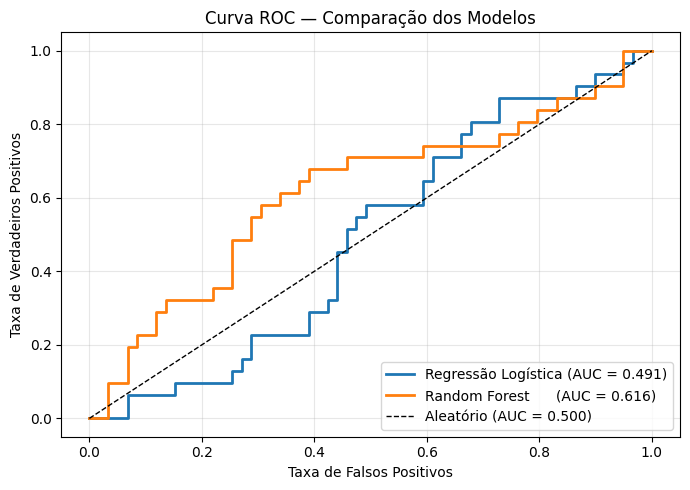

In [ ]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {auc_lr:.3f})', linewidth=2)
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest      (AUC = {auc_rf:.3f})', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)', linewidth=1)
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Comparação dos Modelos')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

rf_bal = RandomForestClassifier(
    max_depth=4, n_estimators=100,
    class_weight='balanced', random_state=42
)
rf_bal.fit(X_train, y_train)
y_prob_bal = rf_bal.predict_proba(X_test)[:, 1]

auc_bal = roc_auc_score(y_test, y_prob_bal)
print(f"ROC-AUC (balanced): {auc_bal:.4f}  |  ROC-AUC (original): {auc_rf:.4f}\n")

def matriz_threshold(threshold, y_true, y_prob, label):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    acc    = accuracy_score(y_true, y_pred)
    print(f"  Threshold = {threshold}  ({label})")
    print(f"  {'Acurácia':12}: {acc:.4f}  |  Precisão: {prec:.4f}  |  Recall: {rec:.4f}  |  F1: {f1:.4f}")
    print(f"  Matriz de Confusão:")
    print(f"    TN={tn}  FP={fp}")
    print(f"    FN={fn}  TP={tp}")
    print(f"  (Inadimplentes detectados: {tp}/{tp+fn}  |  Alarmes falsos: {fp})\n")

print("=" * 60)
print("  Random Forest — class_weight='balanced'")
print("=" * 60)
for thr in [0.35, 0.40]:
    matriz_threshold(thr, y_test, y_prob_bal, f"balanced RF")

ROC-AUC (balanced): 0.6107  |  ROC-AUC (original): 0.6162

  Random Forest — class_weight='balanced'
  Threshold = 0.35  (balanced RF)
  Acurácia    : 0.4000  |  Precisão: 0.3380  |  Recall: 0.7742  |  F1: 0.4706
  Matriz de Confusão:
    TN=12  FP=47
    FN=7  TP=24
  (Inadimplentes detectados: 24/31  |  Alarmes falsos: 47)

  Threshold = 0.4  (balanced RF)
  Acurácia    : 0.5222  |  Precisão: 0.3889  |  Recall: 0.6774  |  F1: 0.4941
  Matriz de Confusão:
    TN=26  FP=33
    FN=10  TP=21
  (Inadimplentes detectados: 21/31  |  Alarmes falsos: 33)



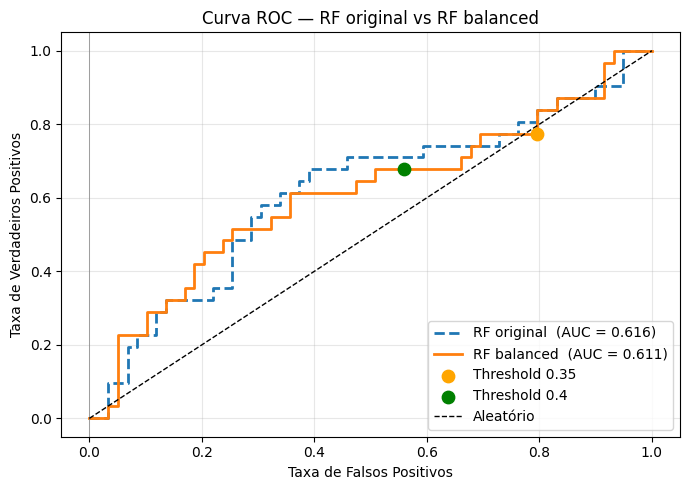

In [ ]:
fpr_bal, tpr_bal, _ = roc_curve(y_test, y_prob_bal)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_rf,  tpr_rf,  label=f'RF original  (AUC = {auc_rf:.3f})',  linewidth=2, linestyle='--')
ax.plot(fpr_bal, tpr_bal, label=f'RF balanced  (AUC = {auc_bal:.3f})', linewidth=2)
ax.axvline(x=0, color='gray', linewidth=0.5)

for thr, color in [(0.35, 'orange'), (0.40, 'green')]:
    y_pred_thr = (y_prob_bal >= thr).astype(int)
    fpr_pt = (y_pred_thr[(y_test == 0)].sum()) / (y_test == 0).sum()
    tpr_pt = (y_pred_thr[(y_test == 1)].sum()) / (y_test == 1).sum()
    ax.scatter(fpr_pt, tpr_pt, s=80, color=color, zorder=5, label=f'Threshold {thr}')

ax.plot([0, 1], [0, 1], 'k--', label='Aleatório', linewidth=1)
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — RF original vs RF balanced')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Ranking de Feature Importance — RF (balanced, max_depth=4)

  #  Variável                         Importância   % Acumulado
-----------------------------------------------------------------
  1  SCORE_CREDITO                         19.96%        19.96%
  2  RENDA_ESTIMADA                        19.46%        39.43%
  3  COMPROMETIMENTO_RENDA                 11.55%        50.97%
  4  VALOR_EMPRESTADO                      10.74%        61.71%
  5  PROFISSAO_unknown                      8.87%        70.58%
  6  IDADE                                  8.26%        78.84%
  7  PRAZO_MESES                            7.98%        86.82%
  8  REGIAO_NORDESTE                        4.58%        91.40%
  9  PROFISSAO_autonomous                   1.30%        92.69%
 10  PROFISSAO_wage_worker                  1.23%        93.92%
 11  PROFISSAO_retired                      1.02%        94.94%
 12  REGIAO_CENTRO-OESTE                    0.98%        95.92%
 13  REGIAO_SUL                           

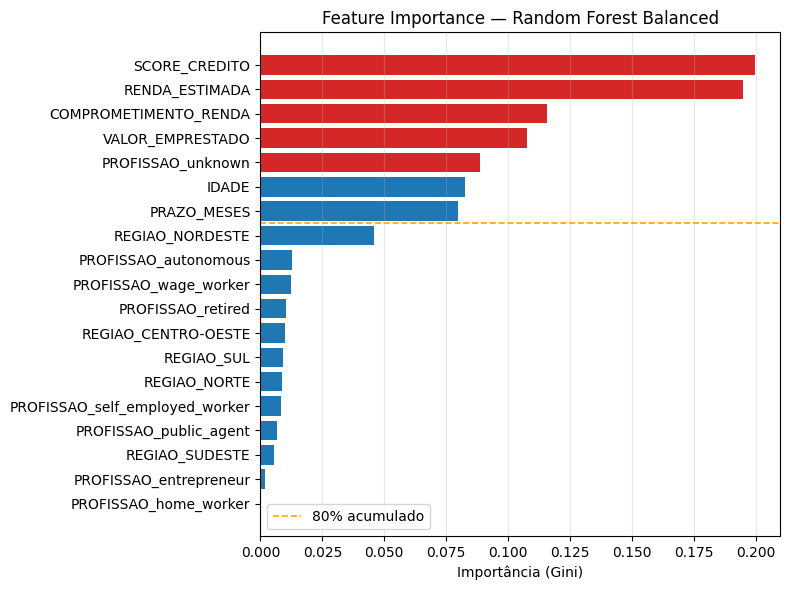

In [ ]:
fi = (
    pd.DataFrame({
        'feature': X_train.columns,
        'importance': rf_bal.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)
fi['rank'] = fi.index + 1
fi['importance_pct'] = fi['importance'] / fi['importance'].sum() * 100
fi['importance_acum'] = fi['importance_pct'].cumsum()

print("Ranking de Feature Importance — RF (balanced, max_depth=4)\n")
print(f"{'#':>3}  {'Variável':<30}  {'Importância':>12}  {'% Acumulado':>12}")
print("-" * 65)
for _, row in fi.iterrows():
    print(f"{row['rank']:>3}  {row['feature']:<30}  {row['importance_pct']:>11.2f}%  {row['importance_acum']:>11.2f}%")

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#d62728' if i < 5 else '#1f77b4' for i in range(len(fi))]
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=colors[::-1])
ax.set_xlabel('Importância (Gini)')
ax.set_title('Feature Importance — Random Forest Balanced')
ax.grid(axis='x', alpha=0.3)

top_n = (fi['importance_acum'] <= 80).sum() + 1
ax.axhline(y=len(fi) - top_n - 0.5, color='orange', linestyle='--', linewidth=1.2, label='80% acumulado')
ax.legend()
plt.tight_layout()
plt.show()

  Distribuição das top-3 features por classe (treino)

  SCORE_CREDITO
    Adimplente  → mediana: 775.50  |  média: 779.79  |  p25: 741.00  |  p75: 821.50
    Inadimplente→ mediana: 775.50  |  média: 759.63  |  p25: 725.25  |  p75: 784.50

  RENDA_ESTIMADA
    Adimplente  → mediana: 1975.00  |  média: 2744.57  |  p25: 1350.00  |  p75: 4125.00
    Inadimplente→ mediana: 2150.00  |  média: 2425.00  |  p25: 1650.00  |  p75: 2300.00

  COMPROMETIMENTO_RENDA
    Adimplente  → mediana: 0.14  |  média: 0.17  |  p25: 0.10  |  p75: 0.22
    Inadimplente→ mediana: 0.14  |  média: 0.15  |  p25: 0.09  |  p75: 0.20

  Thresholds mais frequentes nas árvores do RF balanced

  SCORE_CREDITO
    Splits utilizados : 139
    Mediana dos splits: 801.50
    Bin mais frequente: [795.00, 804.88]  (29 árvores)

  RENDA_ESTIMADA
    Splits utilizados : 140
    Mediana dos splits: 2012.50
    Bin mais frequente: [1360.00, 1702.50]  (42 árvores)

  COMPROMETIMENTO_RENDA
    Splits utilizados : 127
    Mediana do

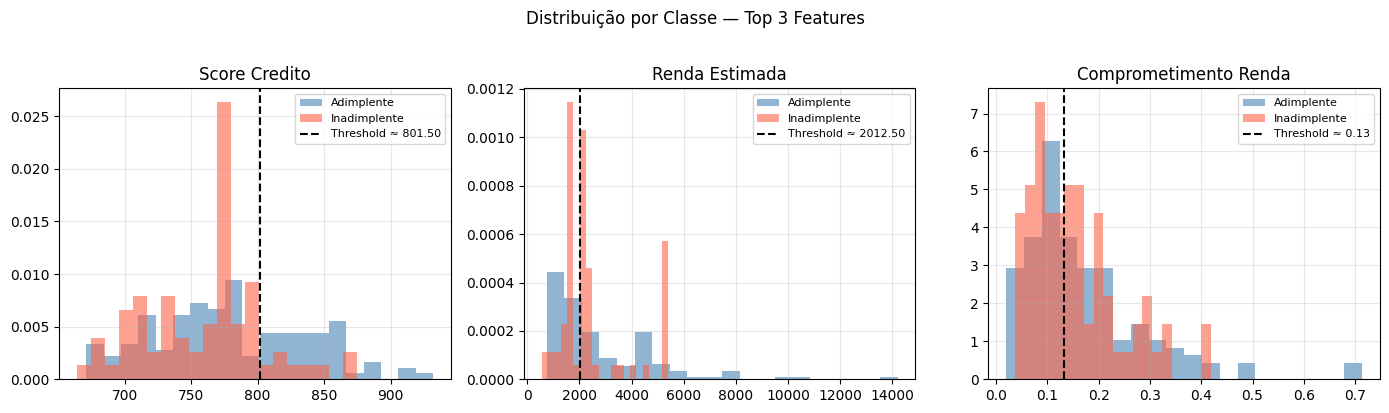

In [ ]:
top3 = ['SCORE_CREDITO', 'RENDA_ESTIMADA', 'COMPROMETIMENTO_RENDA']

df_analise = X_train.copy()
df_analise['INADIMPLENTE'] = y_train.values

print("=" * 65)
print("  Distribuição das top-3 features por classe (treino)")
print("=" * 65)
for feat in top3:
    adim  = df_analise.loc[df_analise['INADIMPLENTE'] == 0, feat]
    inad  = df_analise.loc[df_analise['INADIMPLENTE'] == 1, feat]
    print(f"\n  {feat}")
    print(f"    Adimplente  → mediana: {adim.median():.2f}  |  média: {adim.mean():.2f}  |  p25: {adim.quantile(0.25):.2f}  |  p75: {adim.quantile(0.75):.2f}")
    print(f"    Inadimplente→ mediana: {inad.median():.2f}  |  média: {inad.mean():.2f}  |  p25: {inad.quantile(0.25):.2f}  |  p75: {inad.quantile(0.75):.2f}")

from collections import defaultdict

feat_index = {f: list(X_train.columns).index(f) for f in top3}
splits = defaultdict(list)

for estimator in rf_bal.estimators_:
    tree = estimator.tree_
    for node in range(tree.node_count):
        feat_id = tree.feature[node]
        if feat_id < 0:  # folha
            continue
        fname = X_train.columns[feat_id]
        if fname in top3:
            splits[fname].append(tree.threshold[node])

print("\n" + "=" * 65)
print("  Thresholds mais frequentes nas árvores do RF balanced")
print("=" * 65)
for feat in top3:
    vals = pd.Series(splits[feat])
    counts, edges = np.histogram(vals, bins=20)
    peak_bin = edges[counts.argmax()]
    peak_bin_end = edges[counts.argmax() + 1]
    print(f"\n  {feat}")
    print(f"    Splits utilizados : {len(vals)}")
    print(f"    Mediana dos splits: {vals.median():.2f}")
    print(f"    Bin mais frequente: [{peak_bin:.2f}, {peak_bin_end:.2f}]  ({counts.max()} árvores)")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, top3):
    adim = df_analise.loc[df_analise['INADIMPLENTE'] == 0, feat]
    inad = df_analise.loc[df_analise['INADIMPLENTE'] == 1, feat]
    ax.hist(adim, bins=20, alpha=0.6, label='Adimplente', color='steelblue', density=True)
    ax.hist(inad, bins=20, alpha=0.6, label='Inadimplente', color='tomato', density=True)
    thr = pd.Series(splits[feat]).median()
    ax.axvline(thr, color='black', linestyle='--', linewidth=1.5, label=f'Threshold ≈ {thr:.2f}')
    ax.set_title(feat.replace('_', ' ').title())
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
fig.suptitle('Distribuição por Classe — Top 3 Features', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()